# FusionDB reactor browser

Lists all reactors side by side (one column per reactor) with every available field, including derived values. Columns with warnings are highlighted in yellow; mismatches beyond the 1% tolerance are highlighted in red (red overrides yellow). Warning messages are echoed below the table.


In [1]:
from pathlib import Path
import numbers
import time
import warnings
import cProfile
import pstats
import sys

def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / 'reactors').is_dir() and (path / 'src' / 'fusdb').is_dir():
            return path
    return start

root = find_repo_root(Path.cwd())
src_path = str(root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pandas as pd  # Pandas is required for styling
from IPython.display import display

# Import current API
from fusdb.reactor_class import Reactor
from fusdb.utils import as_profile_array
from fusdb.variable_util import make_variable


In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

PROFILE_TOP = 25
profiler = cProfile.Profile()
profiler.enable()

warnings.filterwarnings("ignore", message="Unknown solver tag 'verbosity'.*")

# Load reactors from YAML format
reactors = {}
computed_flags: dict[tuple[str, str], bool] = {}
input_status: dict[tuple[str, str], str] = {}
warning_messages: dict[str, list[str]] = {}
explicit_params_by_reactor: dict[str, set[str]] = {}
variable_status: dict[tuple[str, str], object] = {}
variable_rank: dict[tuple[str, str], int | None] = {}
relation_status: dict[tuple[str, str], object] = {}

LOG_STAGE_TIMES = True

# Metadata fields
metadata_fields = ['id', 'name', 'organization', 'country', 'year', 'doi', 'notes']

def log(msg: str) -> None:
    print(msg)

def numeric_value(value: object) -> float | None:
    """Extract a comparable scalar from value/profile types."""
    profile = as_profile_array(value)
    if profile is not None:
        return float(profile.mean())

    try:
        import numpy as np
    except Exception:
        np = None

    if np is not None:
        if isinstance(value, np.ndarray):
            if value.size == 1:
                return float(value.item())
            return None
        if isinstance(value, np.generic):
            try:
                return float(value.item())
            except Exception:
                return None

    if isinstance(value, numbers.Real) and not isinstance(value, bool):
        return float(value)

    try:
        import sympy as sp
    except Exception:
        sp = None

    if sp is not None and isinstance(value, sp.Expr) and value.is_number:
        try:
            return float(value.evalf())
        except Exception:
            return None

    try:
        return float(value)
    except Exception:
        return None

def to_display_value(value: object) -> object:
    """Convert value to a compact display string or scalar."""
    profile = as_profile_array(value)
    if profile is not None:
        if profile.size == 0:
            return "profile(n=0)"
        mean_val = float(profile.mean())
        min_val = float(profile.min())
        max_val = float(profile.max())
        mean_text = f"{mean_val:.3g}".replace("e+0", "e").replace("e+", "e")
        min_text = f"{min_val:.3g}".replace("e+0", "e").replace("e+", "e")
        max_text = f"{max_val:.3g}".replace("e+0", "e").replace("e+", "e")
        return f"profile(n={profile.size}, mean={mean_text}, min={min_text}, max={max_text})"

    try:
        import numpy as np
    except Exception:
        np = None

    if np is not None and isinstance(value, np.ndarray):
        if value.size == 1:
            return float(value.item())
        return f"array({value.size})"

    try:
        import sympy as sp
    except Exception:
        sp = None

    if sp is not None and isinstance(value, sp.Expr) and value.is_number:
        try:
            return float(value.evalf())
        except Exception:
            return value
    return value

def format_sci(value: object) -> str:
    """Format value for scientific notation if needed."""
    if isinstance(value, str):
        return value
    if isinstance(value, numbers.Real) and not isinstance(value, bool):
        if value != 0 and (abs(value) >= 1e4 or abs(value) <= 1e-4):
            return f"{value:.2e}"
    if value is None:
        return ""
    return str(value)

def exact_match(base: object, other: object, eps: float = 1e-12) -> bool:
    """Check if two values match (arrays compared element-wise)."""
    base_prof = as_profile_array(base)
    other_prof = as_profile_array(other)
    if base_prof is not None or other_prof is not None:
        if base_prof is None or other_prof is None:
            return False
        if base_prof.shape != other_prof.shape:
            return False
        import numpy as np
        return bool(np.allclose(base_prof, other_prof, rtol=eps, atol=eps))

    base_num = numeric_value(base)
    other_num = numeric_value(other)
    if base_num is None or other_num is None:
        return False
    scale = max(abs(base_num), abs(other_num), 1.0)
    return abs(base_num - other_num) <= eps * scale

def classify_input_status(input_val: object, solved_val: object, tol: float = 0.01) -> str:
    """Classify consistency between input and solved values."""
    input_num = numeric_value(input_val)
    solved_num = numeric_value(solved_val)
    if input_num is None or solved_num is None:
        return "none"
    delta = solved_num - input_num
    if delta == 0:
        return "green"
    scale = max(abs(input_num), abs(solved_num), 1.0)
    if abs(delta) <= tol * scale:
        return "yellow"
    return "red"

log(f"Loading reactors from {root.resolve()}")

# Find all reactor directories
reactor_dirs = []
reactors_path = root / 'reactors'
if reactors_path.is_dir():
    for item in reactors_path.iterdir():
        if item.is_dir():
            yaml_path = item / 'reactor.yaml'
            if yaml_path.exists():
                reactor_dirs.append((item, yaml_path))

for reactor_dir, yaml_path in reactor_dirs:
    log(f"Loading {reactor_dir.name} from {yaml_path.name}...")
    t0 = time.perf_counter()
    try:
        reactor = Reactor.from_yaml(yaml_path)
        t_loaded = time.perf_counter()
        try:
            reactor.solve()
        except Exception as e:
            log(f"  ERROR solving reactor: {e}")
        t_solved = time.perf_counter()
    except Exception as e:
        log(f"  ERROR loading reactor: {e}")
        import traceback
        traceback.print_exc()
        continue

    load_elapsed = time.perf_counter() - t0
    log(f"  Loaded reactor in {load_elapsed:.2f}s")
    if LOG_STAGE_TIMES:
        log(f"  - parse/load: {t_loaded - t0:.2f}s")
        log(f"  - solve: {t_solved - t_loaded:.2f}s")

    # Get reactor ID from reactor properties
    reactor_id = reactor.id or reactor_dir.name
    reactors[reactor_id] = reactor

    # Determine which variables were explicitly provided
    explicit_params = {
        name for name, var in reactor.variables_dict.items()
        if var.input_source == "explicit"
    }
    explicit_params_by_reactor[reactor_id] = explicit_params

    # Track which variables were computed vs explicit
    for name, var in reactor.variables_dict.items():
        input_val = var.input_value
        current_val = var.current_value if var.current_value is not None else input_val
        computed_present = (
            var.current_value is not None
            and (var.input_source is None or not exact_match(var.input_value, var.current_value))
        )
        computed_flags[(name, reactor_id)] = computed_present
        input_status[(name, reactor_id)] = classify_input_status(input_val, current_val)

    # Capture variable validity status from solver diagnostics
    t_diag = time.perf_counter()
    try:
        diag = reactor.diagnose()
        for name, status, rank in diag["variable_issues"]:
            variable_status[(name, reactor_id)] = status
            variable_rank[(name, reactor_id)] = rank
        for rel_name, status, _residual in diag["violated_relations"]:
            relation_status[(reactor_id, rel_name)] = status
    except Exception as e:
        warning_messages.setdefault(reactor_id, []).append(f"diagnose failed: {e}")
    t_diag_done = time.perf_counter()
    if LOG_STAGE_TIMES:
        log(f"  - diagnostics: {t_diag_done - t_diag:.2f}s")

    warning_messages[reactor_id] = warning_messages.get(reactor_id, [])

profiler.disable()
pstats.Stats(profiler).sort_stats("cumtime").print_stats(PROFILE_TOP)


Loading reactors from /home/alessmor/Scrivania/fusdb
Loading HAMMIR from reactor.yaml...
  Loaded reactor in 0.95s
  - parse/load: 0.35s
  - solve: 0.60s
  - diagnostics: 0.16s
Loading STEP_2024 from reactor.yaml...


Inconsistency: relation 'I_p' computed beta_N = 3.92, but input specifies beta_N = 0.0393
Inconsistency: relation 'B0' computed beta_T = 0.125, but input specifies beta_T = 0.139
_execute_pass: breaking after 101 iterations
Inconsistency: overriding beta_N by 2 -> 3.918942731277534
_execute_pass: breaking after 101 iterations
Inconsistency: overriding beta_T by 0.0462 -> 0.12498212883436052 (global)
_execute_pass: breaking after 101 iterations
Inconsistency: overriding beta_N by 1.95 -> 3.5237252182374776
_execute_pass: breaking after 101 iterations
Soft constraint violated (relation beta_limit): troyon_margin <= 0


  Loaded reactor in 2.74s
  - parse/load: 0.90s
  - solve: 1.84s
  - diagnostics: 0.18s
Loading DEMO_2022 from reactor.yaml...


Volume consistency warning: integral(dV)=2465.2 differs from V_p=2568.18 (rel_delta=4.010%, tol=1%).
Inconsistency: relation 'A_p' computed P_LH = 1.74e+08, but input specifies P_LH = 1.21e+08
Inconsistency: relation 'P_fus_TT' computed P_fus = 2.24e+09, but input specifies P_fus = 2e+09
_execute_pass: breaking after 101 iterations
Inconsistency: overriding P_LH by 0.159 -> 174267541.7923748
_execute_pass: breaking after 101 iterations
Inconsistency: overriding P_fus by 0.0502 -> 2244914780.432935 (global)
_execute_pass: breaking after 101 iterations
Soft constraint violated (variable f_GW): f_GW <= 1
Soft constraint violated (relation n_GW): greenwald_margin <= 0


  Loaded reactor in 2.90s
  - parse/load: 1.67s
  - solve: 1.23s
  - diagnostics: 0.18s
Loading INFINITY_TWO from reactor.yaml...
  Loaded reactor in 0.56s
  - parse/load: 0.26s
  - solve: 0.29s
  - diagnostics: 0.15s
Loading STELLARIS from reactor.yaml...


Inconsistency: relation 'P_loss' computed tau_E = 0.707, but input specifies tau_E = 1.46
Inconsistency: relation 'P_fus_TT' computed P_fus = 5.27e+09, but input specifies P_fus = 2.7e+09
Inconsistency: overriding tau_E by 0.315 -> 0.7065253320063063
Inconsistency: overriding P_fus by 0.29 -> 5265862356.25401 (global)


  Loaded reactor in 1.00s
  - parse/load: 0.27s
  - solve: 0.74s
  - diagnostics: 0.16s
Loading ARC_2015 from reactor.yaml...


Inconsistency: relation 'I_p' computed beta_N = 2.53, but input specifies beta_N = 2.59
Inconsistency: relation 'P_fus_TT' computed P_fus = 4.39e+08, but input specifies P_fus = 5.25e+08
Volume consistency warning: integral(dV)=136.647 differs from V_p=153 (rel_delta=10.688%, tol=1%).
Inconsistency: overriding beta_N by 0.00977 -> 2.5323589743589743
Inconsistency: overriding P_fus by 0.0778 -> 438938547.9246135
Inconsistency: overriding B0 by 0.0216 -> 8.752975069227904 (global)
Inconsistency: overriding beta_N by 0.0314 -> 2.4093124966195267
Inconsistency: overriding I_p by 0.0216 -> 7421000.602139994 (global)
Inconsistency: overriding beta_N by 0.00977 -> 2.53235897436972


  Loaded reactor in 2.32s
  - parse/load: 0.27s
  - solve: 2.06s
  - diagnostics: 0.18s
         31361284 function calls (30472983 primitive calls) in 11.292 seconds

   Ordered by: cumulative time
   List reduced from 6445 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       23    0.000    0.000   11.484    0.499 /home/alessmor/Scrivania/fusdb/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
  4687/23    0.066    0.000   11.484    0.499 {built-in method builtins.exec}
        1    0.005    0.005   11.483   11.483 /tmp/ipykernel_182561/1570770633.py:1(<module>)
        6    0.000    0.000    6.756    1.126 /home/alessmor/Scrivania/fusdb/src/fusdb/reactor_class.py:164(solve)
        6    0.001    0.000    5.652    0.942 /home/alessmor/Scrivania/fusdb/src/fusdb/relationsystem_class.py:1893(solve)
        6    0.000    0.000    3.706    0.618 /home/alessmor/Scrivania/fusdb/src/fusdb/reactor_class.py

In [3]:
# Build table data
parameter_names = sorted(
    {name for reactor in reactors.values() for name in reactor.variables_dict.keys()},
    key=lambda name: (name.lower(), name),
)
field_names = metadata_fields + parameter_names
log(f"Building table: {len(metadata_fields)} metadata fields, {len(parameter_names)} parameters")
parameter_set = set(parameter_names)

def within_tol(base: object, other: object, rel_tol: float | None, abs_tol: float | None, default_rel: float = 0.01) -> bool:
    """Check if two values are within tolerance."""
    base_num = numeric_value(base)
    other_num = numeric_value(other)
    if base_num is None or other_num is None:
        return False
    if rel_tol is None and abs_tol is None:
        rel = default_rel
        abs_t = 0.0
    else:
        rel = rel_tol or 0.0
        abs_t = abs_tol or 0.0
    scale = max(abs(base_num), abs(other_num), 1.0)
    tol = max(abs_t, rel * scale)
    return abs(base_num - other_num) <= tol

table_data: dict[str, dict[str, object]] = {}
for rid, reactor in sorted(reactors.items()):
    column_data: dict[str, object] = {}
    for name in field_names:
        if name in parameter_set:
            var = reactor.variables_dict.get(name)
            if var is None:
                column_data[name] = ""
                continue

            input_val = var.input_value
            current_val = var.current_value if var.current_value is not None else input_val

            if input_val is None and current_val is None:
                cell_text = ""
            elif input_val is None:
                cell_text = format_sci(to_display_value(current_val))
            elif current_val is None or exact_match(input_val, current_val):
                cell_text = format_sci(to_display_value(input_val))
            else:
                base_str = format_sci(to_display_value(input_val))
                current_str = format_sci(to_display_value(current_val))
                cell_text = f"{base_str} -> {current_str}"

            column_data[name] = cell_text
        else:
            column_data[name] = format_sci(getattr(reactor, name, None))
    table_data[rid] = column_data

df = pd.DataFrame.from_dict(table_data, orient="columns")
df = df.reindex(index=field_names, columns=sorted(reactors.keys()))
if len(df.columns) != len(reactors):
    log(f"WARNING: expected {len(reactors)} reactor columns, got {len(df.columns)}")

def style_cells(data: pd.DataFrame) -> pd.DataFrame:
    """Style cells based on input/computed status and value consistency."""
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    for field in styles.index:
        for rid in styles.columns:
            parts = ['white-space: pre-line;']
            var = reactors[rid].variables_dict.get(field)
            if var is None:
                styles.loc[field, rid] = ' '.join(parts)
                continue

            input_val = var.input_value
            current_val = var.current_value if var.current_value is not None else input_val

            if var.input_source is not None and input_val is not None:
                if current_val is None or exact_match(input_val, current_val):
                    parts.append('color: #0a7d2a;')
                elif within_tol(input_val, current_val, var.rel_tol, var.abs_tol):
                    parts.append('color: #b58900;')
                else:
                    parts.append('color: #b30000; font-weight: 600;')

            if computed_flags.get((field, rid), False) and current_val is not None:
                parts.append('text-decoration: underline;')

            styles.loc[field, rid] = ' '.join(parts)
    return styles

styled = df.style.apply(style_cells, axis=None)
styled = styled.format(escape=None)
display(styled)

# Show warnings below the table
for rid, msgs in warning_messages.items():
    if not msgs:
        continue
    print(f'Warnings for {rid}:')
    for msg in msgs:
        print(f' - {msg}')


Building table: 7 metadata fields, 105 parameters


,ARC_2015,DEMO_2022,Hammir2024,InfinityTwo2025,STEP2024EBCC,Stellaris2025
id,ARC_2015,DEMO_2022,Hammir2024,InfinityTwo2025,STEP2024EBCC,Stellaris2025
name,ARC 2015,EU-DEMO 2022,Hammir 2024,INFINITY TWO 2025,STEP 2024 EB-CC,Stellaris 2025 - Point A
organization,MIT,EUROFUSION,Realta,TypeOne Energy,UKAEA,Proxima
country,United States,EUU,,,United Kingdom,
year,2015,2022,2024,2025,2024,2025
doi,10.1016/j.fusengdes.2015.07.008,10.1016/j.fusengdes.2022.113080,10.1088/1741-4326/ad3fcb,10.1017/S0022377825000364,10.1088/1741-4326/ad6ea2,10.1016/j.fusengdes.2025.114868
notes,Conceptual compact tokamak from MIT,EU-DEMO Physics Baseline 2022,,,Refers to EC+EBW heating scenario with Conservative Confinement conditions,
A,2.92,3.1,,10.0,1.8,9.8
a,1.13,2.9,,1.25,2.0,1.3
A_p,232.37218811842646,1554.4050448854432,,,600.3569688145529,327.0


In [4]:
# Display reactor info using the new __repr__ method
print("Loaded reactors:")
for rid, reactor in sorted(reactors.items()):
    print(f"  {reactor}")


Loaded reactors:
  Reactor(id='ARC_2015', name='ARC 2015', org='MIT', year=2015, 93 variables, 96 relations)
  Reactor(id='DEMO_2022', name='EU-DEMO 2022', org='EUROFUSION', year=2022, 87 variables, 98 relations)
  Reactor(id='Hammir2024', name='Hammir 2024', org='Realta', year=2024, 49 variables, 84 relations)
  Reactor(id='InfinityTwo2025', name='INFINITY TWO 2025', org='TypeOne Energy', year=2025, 33 variables, 86 relations)
  Reactor(id='STEP2024EBCC', name='STEP 2024 EB-CC', org='UKAEA', year=2024, 83 variables, 99 relations)
  Reactor(id='Stellaris2025', name='Stellaris 2025 - Point A', org='Proxima', year=2025, 76 variables, 86 relations)


In [5]:
# Prepare reactors for plotting (use all loaded reactors)
plot_reactors = reactors
log(f"Plotting all reactors: {', '.join(sorted(plot_reactors))}")


Plotting all reactors: ARC_2015, DEMO_2022, Hammir2024, InfinityTwo2025, STEP2024EBCC, Stellaris2025


Skipping Hammir2024: Missing 95% geometry variables for plotting: R, a, kappa_95, delta_95
Skipping InfinityTwo2025: Missing 95% geometry variables for plotting: kappa_95, delta_95
Skipping Stellaris2025: Missing 95% geometry variables for plotting: kappa_95, delta_95


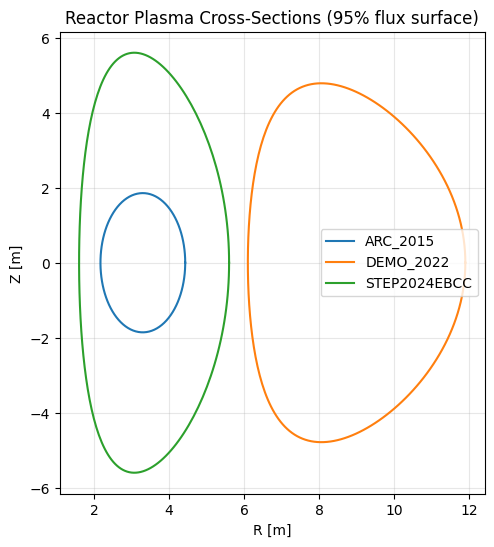

In [6]:
# Plot plasma cross-sections for all loaded reactors
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
plotted = 0

for name, reactor in sorted(plot_reactors.items()):
    try:
        reactor.plot_cross_sections(ax=ax, label=name)
        plotted += 1
    except Exception as e:
        log(f"Skipping {name}: {e}")

if plotted:
    ax.legend()
    plt.title('Reactor Plasma Cross-Sections (95% flux surface)')
    plt.show()
else:
    log("No reactors had sufficient geometry data to plot.")


## POPCON scan example (DEMO)


Inconsistency: relation 'n_avg' computed f_GW = 0.893, but input specifies f_GW = 1.2
Inconsistency: relation 'A_p' computed P_LH = 1.41e+08, but input specifies P_LH = 1.21e+08
Inconsistency: relation 'I_p' computed beta_N = 0.808, but input specifies beta_N = 2.5
Inconsistency: relation 'P_fus_TT' computed P_fus = 1.67e+08, but input specifies P_fus = 2e+09
_execute_pass: breaking after 101 iterations
Volume consistency warning: integral(dV)=2465.2 differs from V_p=2568.18 (rel_delta=4.010%, tol=1%).
Inconsistency: overriding beta_N by 0.49 -> 0.8083226988547194
_execute_pass: breaking after 101 iterations
Inconsistency: overriding f_GW by 0.128 -> 0.8930972692965689
_execute_pass: breaking after 101 iterations
Inconsistency: overriding P_LH by 0.0672 -> 141006120.38970196
_execute_pass: breaking after 101 iterations
Inconsistency: overriding P_fus by 1.08 -> 166654235.37863612 (global)
_execute_pass: breaking after 101 iterations


Text(0.5, 1.0, 'DEMO POPCON: P_fus')

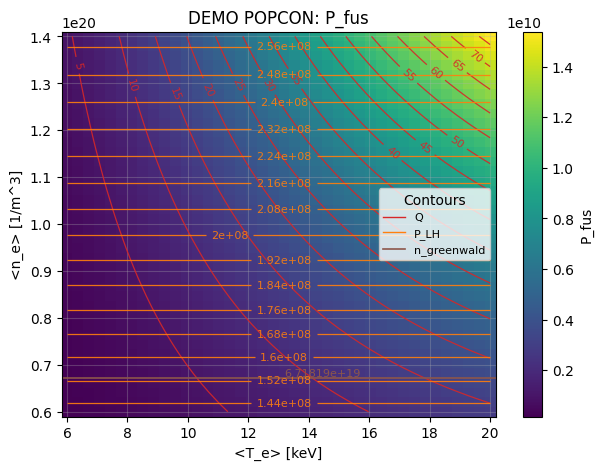

In [7]:
import numpy as np
from fusdb.registry.reactor_defaults import apply_reactor_defaults

# POPCON scan for DEMO over temperature and density.
demo = Reactor.from_yaml(root / "reactors" / "DEMO_2022" / "reactor.yaml")

scan_T = np.linspace(6.0, 20.0, 40)
scan_n = np.linspace(0.6e20, 1.4e20, 40)

# Ensure scan axes exist as explicit scalar inputs.
for name, first_value in (("n_avg", scan_n[0]), ("T_avg", scan_T[0])):
    var = demo.variables_dict.get(name)
    if var is None:
        var = make_variable(name=name, ndim=0, input_source="explicit")
        demo.variables_dict[name] = var
    var.input_value = None
    var.current_value = None
    var.add_value(float(first_value), as_input=True)
    var.input_source = "explicit"

# Clear scalar inputs that should follow averages.
for name in ("n_e", "n_i", "T_e", "T_i"):
    var = demo.variables_dict.get(name)
    if var is None:
        continue
    var.input_value = None
    var.current_value = None
    var.input_source = None

# Refresh defaults/relations after clearing inputs.
new_defaults = apply_reactor_defaults(demo.variables_dict, relations=demo.default_relations)
seen = {(rel.name, (rel._preferred_target if rel._preferred_target is not None else next(iter(rel.numeric_functions), None))) for rel in demo.default_relations}
for rel in new_defaults:
    key = (rel.name, (rel._preferred_target if rel._preferred_target is not None else next(iter(rel.numeric_functions), None)))
    if key in seen:
        continue
    demo.default_relations.append(rel)
    seen.add(key)

demo.relations = list(demo._ordered_relations())

demo.solve()

fill_var = "P_fus"
contour_vars = ["Q_sci", "P_LH", "n_GW"]  # P_aux is fixed in DEMO YAML.
scan_outputs = [fill_var, *contour_vars]
contour_counts = {name: 15 for name in contour_vars}

result = demo.popcon(
    {"T_avg": scan_T, "n_avg": scan_n},
    outputs=scan_outputs,
)

ax = demo.plot_popcon(
    result,
    x="T_avg",
    y="n_avg",
    fill=fill_var,
    contours=contour_vars,
    contour_counts=contour_counts,
    constraint_contours=False,
)
ax.set_xlabel("<T_e> [keV]")
ax.set_ylabel("<n_e> [1/m^3]")
ax.set_title("DEMO POPCON: P_fus")
